In [13]:
import enerhabitat as eh
import pandas as pd
import matplotlib.pyplot as plt
from enerhabitat import config

1. Daniela Cervantes Sedano
2. Emilio Guzmán Oróstico
3. Alejandro Cerda Barroso

14/05/2026

Elegimos la Opción 4 - Colores (absortancias) porque en edificaciones existentes cambiar el color de la envolvente externa es una estrategia de diseño bioclimático económicamente viable  y que tiene un impacto significativo en el confort térmico al interior, medido a través del factor de decremento.

### Factor de decremento

El factor de decremento es una forma de medir el desempeño térmico de un sistema constructivo a través de la razón entre la amplitud diaria de la temperature interior (Ti) y la exterior (Ta). Es una medida de la atenuación o "retraso" de la transferencia de calor por conducción entre el exterior y el interior:

$$FD=\frac{Ti_{\text{max}}-Ti_{\text{min}}}{Ta_{\text{max}}-Ta_{\text{min}}}$$

Se eligió el sistema constructivo 2. Enjarre (mortero) 2 cm + tabique rojo 14 cm y se varió el color del enjarre exterior, cuyos valores de absortancia están en el diccionario colores. Para graficar FD vs "temperatura exterior", se calculó el FD del día medio de cada mes y se graficó contra la amplitud de la temperatura exterior del día medio de ese mes.

In [14]:
print(sorted(config.materials.keys())) #para verificar que se cargan materiales correctos, este comando lo proporcionó Arié cuando le preguntamos por qué no corría el código de la sig. celda: se había modificado los materiales en el *.ini, por lo que se guardó y se reinició el kernel

['mortero', 'tabique']


In [15]:
def temps(color, a, month=5, year=2026): 

    '''Calcular la temperatura interior y exterior (Ta, Ti) de un sistema constructivo en el día medio de un mes con el clima y ubicación el epw en función del color y la absortancia (a) del exterior. Las propiedades de los materiales se obtuvieron de [1]'''

    epw_file = "epw/MEX_MOR_Cuernavaca-Matamoros.Intl.AP.767260_TMYx.2009-2023.epw"

    wall = eh.System(eh.Location(epw_file))
    wall.azimuth = 90
    wall.tilt = 90

    wall.absortance = a
    wall.layers = [("mortero", 0.02), ("tabique", 0.14)]
    wall.location.meanDay(month=month, year=year)

    df = wall.solve()
    df = pd.concat([df, wall.Tsa().asfreq("10min")], axis=1)

    return df

colores

1. blanco 0.25
2. amarillo 0.4
3. gris 0.45
4. verde 0.5
5. rojo ladrillo 0.6


In [16]:
colores = {"blanco":0.25,"amarillo":0.4,"gris":0.45,"verde":0.5,"rojo":0.6}

In [17]:
for color in colores: #crear dfs para cada color y guardarlos con el nombre del color (mayo 2026)
    globals()[color] = temps(color, colores[color]) #globals() es una función que devuelve un diccionario con todas las variables globales, entonces se le asigna a cada variable el resultado de la función temps con el color y su absortancia correspondiente (lo sugirió Github Copilot)
    print()

In [18]:
blanco

,Ti,zenith,elevation,azimuth,equation_of_time,Ta,Ig,Ib,Id,Tn,DeltaTn,Is,Tsa
2026-05-15 00:00:00-06:00,30.308809,141.408924,-51.408924,347.281424,3.669781,22.318788,0.0,0.0,0.0,27.10993,1.5,0.0,22.318788
2026-05-15 00:10:00-06:00,30.233739,141.852768,-51.852768,351.024891,3.669692,22.081728,0.0,0.0,0.0,27.10993,1.5,0.0,22.081728
2026-05-15 00:20:00-06:00,30.156104,142.142432,-52.142432,354.838227,3.669602,21.847995,0.0,0.0,0.0,27.10993,1.5,0.0,21.847995
2026-05-15 00:30:00-06:00,30.075952,142.274361,-52.274361,358.692631,3.669511,21.617837,0.0,0.0,0.0,27.10993,1.5,0.0,21.617837
2026-05-15 00:40:00-06:00,29.993330,142.246903,-52.246903,2.557290,3.669420,21.391499,0.0,0.0,0.0,27.10993,1.5,0.0,21.391499
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-15 23:10:00-06:00,30.644735,136.897299,-46.897299,330.516549,3.652909,23.545022,0.0,0.0,0.0,27.10993,1.5,0.0,23.545022
2026-05-15 23:20:00-06:00,30.583085,138.004826,-48.004826,333.602440,3.652755,23.295185,0.0,0.0,0.0,27.10993,1.5,0.0,23.295185
2026-05-15 23:30:00-06:00,30.518678,138.995353,-48.995353,336.839197,3.652601,23.047379,0.0,0.0,0.0,27.10993,1.5,0.0,23.047379
2026-05-15 23:40:00-06:00,30.451550,139.860206,-49.860206,340.219250,3.652447,22.801871,0.0,0.0,0.0,27.10993,1.5,0.0,22.801871


In [19]:
amarillo

,Ti,zenith,elevation,azimuth,equation_of_time,Ta,Ig,Ib,Id,Tn,DeltaTn,Is,Tsa
2026-05-15 00:00:00-06:00,32.138693,141.408924,-51.408924,347.281424,3.669781,22.318788,0.0,0.0,0.0,27.10993,1.5,0.0,22.318788
2026-05-15 00:10:00-06:00,32.036984,141.852768,-51.852768,351.024891,3.669692,22.081728,0.0,0.0,0.0,27.10993,1.5,0.0,22.081728
2026-05-15 00:20:00-06:00,31.933082,142.142432,-52.142432,354.838227,3.669602,21.847995,0.0,0.0,0.0,27.10993,1.5,0.0,21.847995
2026-05-15 00:30:00-06:00,31.827030,142.274361,-52.274361,358.692631,3.669511,21.617837,0.0,0.0,0.0,27.10993,1.5,0.0,21.617837
2026-05-15 00:40:00-06:00,31.718873,142.246903,-52.246903,2.557290,3.669420,21.391499,0.0,0.0,0.0,27.10993,1.5,0.0,21.391499
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-15 23:10:00-06:00,32.613570,136.897299,-46.897299,330.516549,3.652909,23.545022,0.0,0.0,0.0,27.10993,1.5,0.0,23.545022
2026-05-15 23:20:00-06:00,32.523393,138.004826,-48.004826,333.602440,3.652755,23.295185,0.0,0.0,0.0,27.10993,1.5,0.0,23.295185
2026-05-15 23:30:00-06:00,32.430839,138.995353,-48.995353,336.839197,3.652601,23.047379,0.0,0.0,0.0,27.10993,1.5,0.0,23.047379
2026-05-15 23:40:00-06:00,32.335942,139.860206,-49.860206,340.219250,3.652447,22.801871,0.0,0.0,0.0,27.10993,1.5,0.0,22.801871


In [20]:
for color in colores: #calcular el factor de decremento (FD) para cada color (mayo 2026)y guardarlo con el nombre "FD_color"
    globals()[f"FD_{color}"] = (globals()[color].Ti.max() - globals()[color].Ti.min()) / (globals()[color].Ta.max() - globals()[color].Ta.min())
    print(f"FD_{color} = {globals()[f'FD_{color}']}")

FD_blanco = 0.35438051683947336
FD_amarillo = 0.4508932158906818
FD_gris = 0.4877281521489804
FD_verde = 0.5260745221418079
FD_rojo = 0.6063314606063916


In [21]:
def temps_mensuales(color, a, year=2026): # función que calcula las temperaturas y el FD para cada día medio de cada mes en el TMY del epw, y devuelve un dataframe con las temperaturas y otro con los resultados (le pedimos a Copilot que juntara las 2 funciones definidas anteriormente)
    temperaturas = []
    resultados = []

    for mes in range(1, 13):
        df = temps(color, a, month=mes, year=year)
        df = df.assign(mes=mes)
        temperaturas.append(df)

        ti = df["Ti"]
        ta = df["Ta"]
        resultados.append({
            "mes": mes,
            "Ta_media": ta.mean(),
            "Ta_amp": ta.max() - ta.min(),
            "FD": (ti.max() - ti.min()) / (ta.max() - ta.min()),
        })

    return pd.concat(temperaturas, keys=range(1, 13), names=["mes", "tiempo"]), pd.DataFrame(resultados)


for color, a in colores.items():
    globals()[f"temps_{color}"], globals()[f"FD_{color}"] = temps_mensuales(color, a)
    print(f"{color}: {len(globals()[f'FD_{color}'])} months computed")

blanco: 12 months computed
amarillo: 12 months computed
gris: 12 months computed
verde: 12 months computed
rojo: 12 months computed


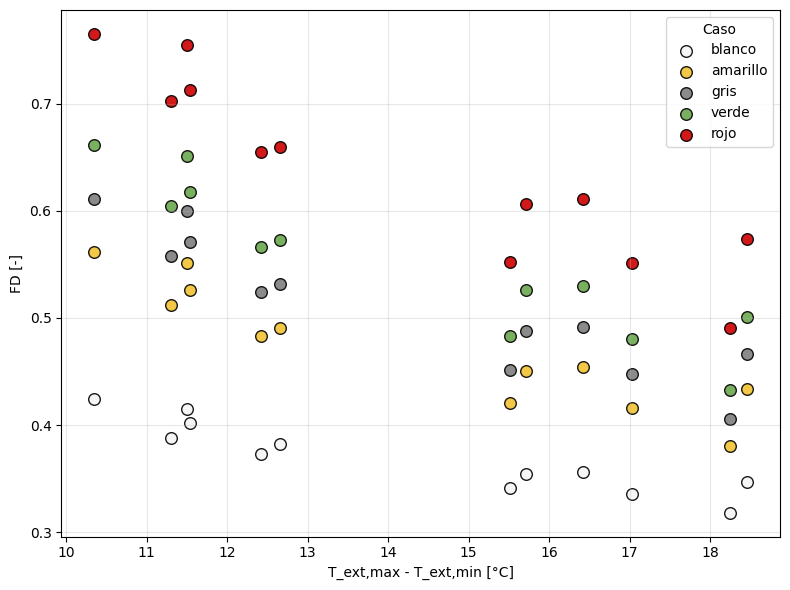

In [22]:
#gráfica de FD vs Ta_amp para cada color, cuando le preguntamos a Arié qué significaba "graficar FD en funcion de Ta" nos sugirió calcular el FD para cada mes y graficarlo en función de la amplitud de la temperatura exterior (Ta_amp) para cada color, entonces se hizo esa gráfica con los datos obtenidos en la función temps_mensuales, y se asignaron colores a cada caso para que se vea más claro (mayo 2026)
# el formato lo dio Github Copilot 
palette = {
    "blanco": "#f5f5f5",
    "amarillo": "#f1c232",
    "gris": "#7f7f7f",
    "verde": "#6aa84f",
    "rojo": "#cc0000",
}

plt.figure(figsize=(8, 6))

for color in colores:
    df_fd = globals()[f"FD_{color}"]
    plt.scatter(
        df_fd["Ta_amp"],
        df_fd["FD"],
        label=color,
        color=palette[color],
        edgecolors="black",
        s=70,
        alpha=0.9,
    )

plt.xlabel("T_ext,max - T_ext,min [°C]")
plt.ylabel("FD [-]")
plt.legend(title="Caso")
plt.grid(True, alpha=0.3)
plt.tight_layout()

In [23]:
epw_file = "epw/MEX_MOR_Cuernavaca-Matamoros.Intl.AP.767260_TMYx.2009-2023.epw" #verificación de los valores de la amplitud de Ta para cada mes. se observa en la gráfica que la amplitud va de 10 a 13 y de 15 a 18, hecho interesante para caracterizar el clima del sitio

wall = eh.System(eh.Location(epw_file))
wall.azimuth = 90
wall.tilt = 90

wall.absortance = 1
wall.layers = [("mortero", 0.02), ("tabique", 0.14)]
wall.location.meanDay(month=12, year=2026)

df = wall.solve()
df = pd.concat([df, wall.Tsa().asfreq("10min")], axis=1)

In [24]:
df.Ta.max() - df.Ta.min()

np.float64(15.515297877588951)

El color es la propiedad de reflejar la longitud de onda correspondiente al color observado, los colores oscuros presentan una mayor absortancia, lo que les permite tener una mayor ganancia térmica superficial. En la gráfica se observa que los factores de decremento son mayores para el color rojo (a=0.6) que el blanco (𝛼=0.25); esto indica que el espacio evaluado presenta menores diferencias con respecto al comportamiento térmico del exterior. En cambio conforme disminuye la absortancia, va disminuyendo el FD, indicando que en las superficies predominan otros efectos ópticos que disminuyen la absorción de calor por radiación solar, lo que permite que el espacio amortigüe los efectos térmicos del exterior con mayor eficiencia que las superficies con colores más oscuros. En la gráfica se puede ver que el color blanco mejor desempeño, con el menor FD para todos los meses.

Por último se observó que cuando la diferencia de temperaturas exteriores disminuye, el FD es más sensible en los colores oscuros, donde tiende a incrementarse y llegar a valores entre 0.6 y 0.8 (poca amortiguación respecto a la temp. exterior). Mientras que, cuando la diferencia de temperaturas exteriores incrementa, el FD disminuye, proporcionando un ambiente con mayor amortiguación térmica. 
Este fenómeno se repite para los diferentes casos, exponiendo que si la diferencia térmica exterior (denominador) aumenta, FD presenta un comportamiento decreciente para todas las absortancias evaluadas. Esto puede deberse al papel que juega el sistema constructivo, indicando que la transferencia de calor del exterior al interior no se transmite proporcionalmente, el tabique está actuando como un aislante térmico y al tener inercia térmica permite que el calor acumulado se libere lentamente, disminuyendo el FD o manteniéndolo. Para la superficie blanca el FD también disminuye conforme la diferencia de temperaturas exteriores es mayor, pero, presenta pocos cambios, manteniéndose entre 0.3 y 0.4.

### Referencias

[1] https://github.com/AltamarMx/validacion_enerhabitat/blob/main/notebook/materials.ini

[2] https://www.engineeringtoolbox.com/solar-radiation-absorbed-materials-d_1568.html

https://www.paint.org/wp-content/uploads/2021/09/jctDEC01-Wang.pdf